In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, filters, measure
# pip install scikit-image

In [2]:
image_pixels = io.imread("images/manyhearts1.jpg")
image_pixels.shape

(1200, 1200, 3)

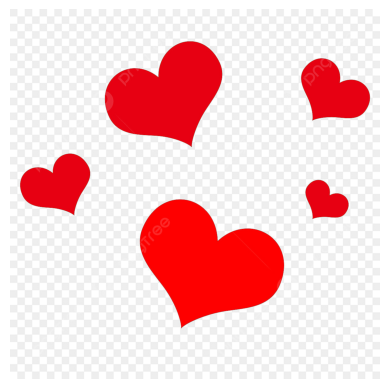

In [18]:
plt.imshow(image_pixels, cmap="gray")
plt.axis("off")
plt.show()

In [3]:
if image_pixels.shape[-1] == 4:
    image_pixels = image_pixels[..., :3]  # discard alpha

In [6]:
gray_img = color.rgb2gray(image_pixels)
gray_img[30:]

array([[1.        , 1.        , 1.        , ..., 0.93333333, 0.93333333,
        0.93333333],
       [1.        , 1.        , 1.        , ..., 0.9372549 , 0.9372549 ,
        0.9372549 ],
       [1.        , 1.        , 1.        , ..., 0.93333333, 0.93333333,
        0.93333333],
       ...,
       [1.        , 1.        , 1.        , ..., 0.93333333, 0.93333333,
        0.93333333],
       [1.        , 1.        , 1.        , ..., 0.93333333, 0.93333333,
        0.93333333],
       [1.        , 1.        , 1.        , ..., 0.93333333, 0.93333333,
        0.93333333]], shape=(1170, 1200))

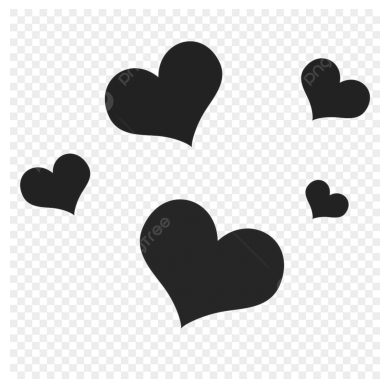

In [7]:
plt.imshow(gray_img, cmap="gray")
plt.axis("off")
plt.show()

In [8]:
edge_sobel = filters.sobel(gray_img)
edge_sobel.shape

(1200, 1200)

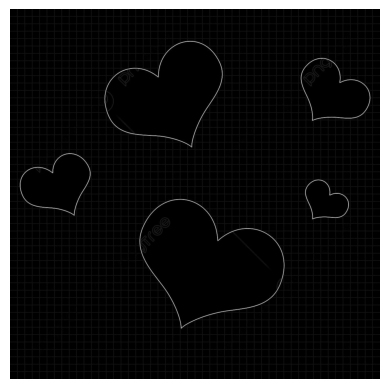

In [9]:
from skimage.util import img_as_ubyte

io.imsave("images/edge_sobel.png", img_as_ubyte(edge_sobel))

plt.imshow(edge_sobel, cmap="gray")
plt.axis("off")
plt.show()

In [15]:
threshold = 0.2
edges = edge_sobel > threshold
edges[100:110,550:570]

array([[False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False,  True,  True,
         True,  True],
       [Fa

In [14]:
edge_pixel_indices = np.nonzero(edges)
edge_pixel_indices

(array([ 104,  104,  104, ..., 1035, 1035, 1036], shape=(9760,)),
 array([572, 573, 574, ..., 555, 556, 555], shape=(9760,)))

In [ ]:
edges[104,572]

In [16]:
edge_points = np.column_stack(np.nonzero(edges))
edge_points[:3]

array([[104, 572],
       [104, 573],
       [104, 574]])

In [17]:
contours = measure.find_contours(edges, level=0.5)
contours

[array([[448.5, 589. ],
        [448.5, 588. ],
        [448. , 587.5],
        ...,
        [447.5, 590. ],
        [448. , 589.5],
        [448.5, 589. ]], shape=(1511, 2)),
 array([[445. , 588.5],
        [444.5, 588. ],
        [444. , 587.5],
        ...,
        [445. , 587.5],
        [445.5, 588. ],
        [445. , 588.5]], shape=(1499, 2)),
 array([[362.5, 981. ],
        [362.5, 980. ],
        [362. , 979.5],
        ...,
        [361.5, 982. ],
        [362. , 981.5],
        [362.5, 981. ]], shape=(887, 2)),
 array([[359. , 982.5],
        [358.5, 983. ],
        [358.5, 984. ],
        ...,
        [359. , 981.5],
        [359.5, 982. ],
        [359. , 982.5]], shape=(873, 2)),
 array([[669.5, 209. ],
        [669.5, 208. ],
        [669.5, 207. ],
        ...,
        [668. , 209.5],
        [669. , 209.5],
        [669.5, 209. ]], shape=(897, 2)),
 array([[665. , 206.5],
        [664. , 206.5],
        [663. , 206.5],
        ...,
        [665.5, 205. ],
        [665.5

In [25]:
test_cont = contours[2]
test_cont.shape

(887, 2)

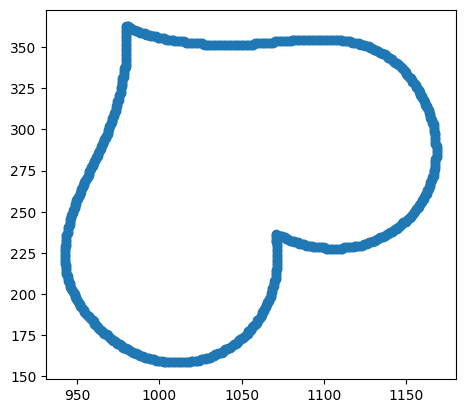

In [24]:
# plot the contour points
plt.plot(test_cont[:, 1], test_cont[:, 0], 'o')
plt.axis('image')
plt.show()

In [81]:
largest_countour_idx = 0
largest_countour_cnt = -1
for i, contour in enumerate(contours):
    n_points = contour.shape[0]
    if n_points < 20:
        continue

    if n_points > largest_countour_cnt:
        largest_countour_cnt = n_points
        largest_countour_idx = i
        print(f"New largest contour: {n_points}")

        y_vals = contour[:, 0]
        x_vals = contour[:, 1]

x_vals.shape, y_vals.shape

New largest contour: 1511
New largest contour: 1859


((1859,), (1859,))

In [80]:
t = np.arange(len(y_vals))
n = len(t)
n, t

(1859, array([   0,    1,    2, ..., 1856, 1857, 1858], shape=(1859,)))

In [66]:
max_n = 500

if n > max_n:
    y_vals = y_vals[::int(n/max_n)]
    x_vals = x_vals[::int(n/max_n)]
    n = len(x_vals)
    t = np.arange(n)
y_vals, y_vals, t

(array([1036.5, 1035. , 1032. , 1029. , 1026.5, 1024. , 1021. , 1019. ,
        1016. , 1014. , 1011. , 1009. , 1006.5, 1004. , 1002. ,  999.5,
         997. ,  995. ,  993. ,  990.5,  988. ,  986. ,  984. ,  982. ,
         979.5,  977.5,  975. ,  973. ,  971. ,  969. ,  967. ,  965. ,
         963. ,  961. ,  959. ,  957. ,  954.5,  952.5,  950.5,  948.5,
         947. ,  945. ,  943. ,  941. ,  939. ,  937. ,  935. ,  933. ,
         931. ,  929.5,  927.5,  926. ,  924. ,  922. ,  920. ,  918.5,
         916.5,  915. ,  913. ,  911. ,  909.5,  907.5,  906. ,  904. ,
         902.5,  900.5,  899. ,  897. ,  895.5,  894. ,  892. ,  890.5,
         889. ,  887. ,  885. ,  883.5,  882. ,  880.5,  878.5,  877. ,
         875. ,  873.5,  872. ,  870. ,  868.5,  866.5,  865. ,  863. ,
         861.5,  860. ,  858. ,  856.5,  854.5,  853. ,  851. ,  849.5,
         847.5,  846. ,  844. ,  842. ,  840.5,  838.5,  837. ,  835. ,
         833. ,  831. ,  829.5,  827.5,  825.5,  824. ,  822. , 

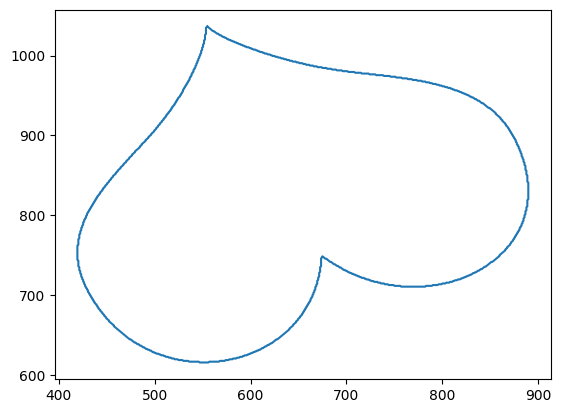

In [82]:
plt.plot(x_vals, y_vals)
plt.show()

In [ ]:
poly_n = n-1
coeffs_x = np.polyfit(t, x_vals, deg=poly_n)
coeffs_y = np.polyfit(t, y_vals, deg=poly_n)
n, t

In [56]:
t_for_plot = np.linspace(0, n-1, 300)
x_poly = np.polyval(coeffs_x, t_for_plot)
y_poly = np.polyval(coeffs_y, t_for_plot)
t_for_plot, x_poly, y_poly

(array([ 0.        ,  0.16722408,  0.33444816,  0.50167224,  0.66889632,
         0.8361204 ,  1.00334448,  1.17056856,  1.33779264,  1.50501672,
         1.6722408 ,  1.83946488,  2.00668896,  2.17391304,  2.34113712,
         2.5083612 ,  2.67558528,  2.84280936,  3.01003344,  3.17725753,
         3.34448161,  3.51170569,  3.67892977,  3.84615385,  4.01337793,
         4.18060201,  4.34782609,  4.51505017,  4.68227425,  4.84949833,
         5.01672241,  5.18394649,  5.35117057,  5.51839465,  5.68561873,
         5.85284281,  6.02006689,  6.18729097,  6.35451505,  6.52173913,
         6.68896321,  6.85618729,  7.02341137,  7.19063545,  7.35785953,
         7.52508361,  7.69230769,  7.85953177,  8.02675585,  8.19397993,
         8.36120401,  8.52842809,  8.69565217,  8.86287625,  9.03010033,
         9.19732441,  9.36454849,  9.53177258,  9.69899666,  9.86622074,
        10.03344482, 10.2006689 , 10.36789298, 10.53511706, 10.70234114,
        10.86956522, 11.0367893 , 11.20401338, 11.3

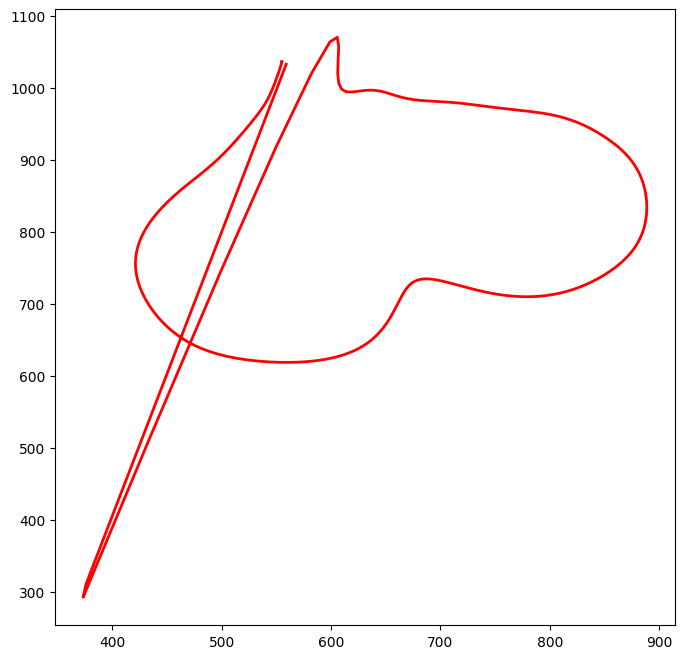

In [57]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(x_poly, y_poly, color="red", linewidth=2)

In [83]:
# pip install scipy
from scipy.interpolate import CubicSpline

In [84]:
sx = CubicSpline(t, x_vals, bc_type="natural")
sy = CubicSpline(t, y_vals, bc_type="natural")

In [85]:
t_for_plot = np.linspace(0, n-1, 5000)
x_poly = sx(t_for_plot)
y_poly = sy(t_for_plot)

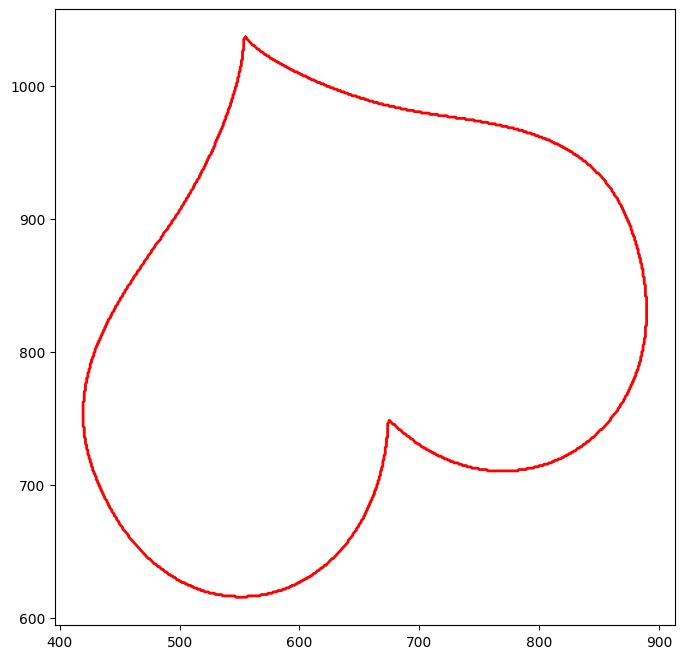

In [86]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(x_poly, y_poly, color="red", linewidth=2)